In [1]:
from deap import creator, base, tools, algorithms
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

# Загрузка и предобработка данных

In [2]:
df = pd.read_csv('D:\Python\РЗС\Automated_RSZ_distribution_enc.csv', sep=';')
df = df.sort_values(['№ схемы/риска', 'Дата изменения статуса РСЗ'])

C:\Users\zincc\AppData\Local\Temp\ipykernel_18268\2901426161.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\Python\РЗС\Automated_RSZ_distribution_enc.csv', sep=';')


In [3]:
drop_list = df[(df['Инспектор, сменивший статус'].isna()) & (df['Статус РСЗ'] != 'Новое')]['№ схемы/риска'].unique()
df = df.drop(index=df[df['№ схемы/риска'].isin(drop_list)].index)
df.loc[df['Код НО инспектора, сменившего стат']=='000n', 'Код НО инспектора, сменившего стат'] = 0

In [4]:
df.drop_duplicates(inplace=True)
df['Дата выявления'] = pd.to_datetime(df['Дата выявления'], format='%Y-%m-%d %H:%M:%S')
df['Дата изменения статуса РСЗ'] = pd.to_datetime(df['Дата изменения статуса РСЗ'], format='%Y-%m-%d %H:%M:%S')
df['Код НО инспектора, сменившего стат'] = df['Код НО инспектора, сменившего стат'].astype(int)

In [5]:
print("Общая информация о данных:")
print(f'Общее количество записей: {df.__len__()}')
print(f'Столбцы: {df.columns.to_list()}')

# Анализ статусов
print("\nРаспределение по статусам:")
print(df['Статус РСЗ'].value_counts())

# Анализ типов задач
print("\nРаспределение по типам:")
print(df['Тип'].value_counts())

Общая информация о данных:
Общее количество записей: 1373796
Столбцы: ['№ схемы/риска', 'Тип', 'Дата выявления', 'Статус РСЗ', 'Дата изменения статуса РСЗ', 'Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат', 'Потенциальный ущерб, руб', 'Номер проверки', 'ИНН НП', 'КПП', 'Наименование НП', 'Рег. номер декларации', 'Код периода', 'Период', 'Год декларации', 'Номер корректировки', 'Дата подачи декларации', 'Вид налога', 'Тип декларации', 'Дата обновления', 'Дата аннулирования НД', 'Дата окончания КНП']

Распределение по статусам:
Статус РСЗ
В работе                                                 563008
Новое                                                    331589
Нарушение подтверждено. Устранено уточнением сведений    161373
Нарушение не подтверждено                                128759
Нарушение подтверждено. Доказано                          62001
Установлены отрицательные изменения                       59883
Нарушение подтверждено. Не доказано                   

In [6]:
# Анализ инспекторов
print('Распределение по инспекторам')
print(df['Инспектор, сменивший статус'].value_counts())

Распределение по инспекторам
Инспектор, сменивший статус
30250-fzog-omkeqi-eoszfzxy    42098
75845-oadk-xuuthe-iorbemnl    13638
56214-vxdc-qmbdkl-lgvrvnzm     7195
99404-xycu-argxqc-vbquafed     5432
33199-xfft-ohhuuq-yhngrscb     5104
                              ...  
53080-pmcv-dkcfvg-fnapfwfa        1
20297-thuo-ejvlfl-ylwhhrlj        1
79662-kvdb-cccfbk-uhguuekp        1
71328-fgit-apqqzm-yvciojaw        1
82985-cqdf-pxgqoq-dmckiobz        1
Name: count, Length: 12631, dtype: int64


In [7]:
df['Тип'] = df['Тип'].replace(
    to_replace={
        'Риск_долго': 'RISK_LONG',
        'Риск_быстро': 'RISK_SHORT',
        'Схема': 'SCHEMA', 
        'Задание': 'Task'
    },
    regex=True)

In [8]:
df[['Статус РСЗ', 'Потенциальный ущерб, руб', 'Номер проверки', 'ИНН НП', 'КПП', 'Наименование НП', 'Рег. номер декларации', 'Код периода', 'Период', 'Год декларации', 'Номер корректировки', 'Дата подачи декларации', 'Вид налога', 'Тип декларации', 'Дата обновления', 'Дата аннулирования НД', 'Дата окончания КНП']].sample(1)

,Статус РСЗ,"Потенциальный ущерб, руб",Номер проверки,ИНН НП,КПП,Наименование НП,Рег. номер декларации,Код периода,Период,Год декларации,Номер корректировки,Дата подачи декларации,Вид налога,Тип декларации,Дата обновления,Дата аннулирования НД,Дата окончания КНП
1317012,Новое,5068845.36,1-6685-25032024-129,837-ywl-vgwq-zousa,8515-qhd-vgsk-iqdnb,24-qhzsrsj-jsbfrmq-ggstgcy,84352139-igwg-ywty-icfr,34,год,2023,0,2024-03-25 00:00:00,УСН,"Налоговая декларация по налогу, уплачиваемому ...",2024-04-10 07:20:06,NaN,2024-06-25 00:00:00


In [9]:
# анализ количества новых задач
grouped_analiz_df = df.groupby('№ схемы/риска')[['Статус РСЗ', 'Тип', 'Инспектор, сменивший статус']].last()
grouped_analiz_df[grouped_analiz_df['Статус РСЗ'] == 'Новое']

,Статус РСЗ,Тип,"Инспектор, сменивший статус"
№ схемы/риска,,,
7811755,Новое,RISK_LONG,89120-mlcy-zfmxhy-fgtqkdha
9346950,Новое,RISK_LONG,18706-pgkm-knwplp-czmgyvoo
9430063,Новое,RISK_SHORT,39595-iful-eeesji-xypdujsm
9446746,Новое,RISK_SHORT,92879-ouuz-eqgodz-geeaocfi
9448905,Новое,RISK_SHORT,45970-yoaz-dzjrks-gkqykphy
9451172,Новое,RISK_SHORT,21123-nonl-tfkwzs-eqhejekk
9951162,Новое,RISK_LONG,19641-tfbs-fcnkjf-rrrcqtkz
10280672,Новое,RISK_SHORT,86949-sstj-jxoiyx-jktfaawu
10297671,Новое,RISK_SHORT,70452-xztv-gbtooq-tpatiyzp


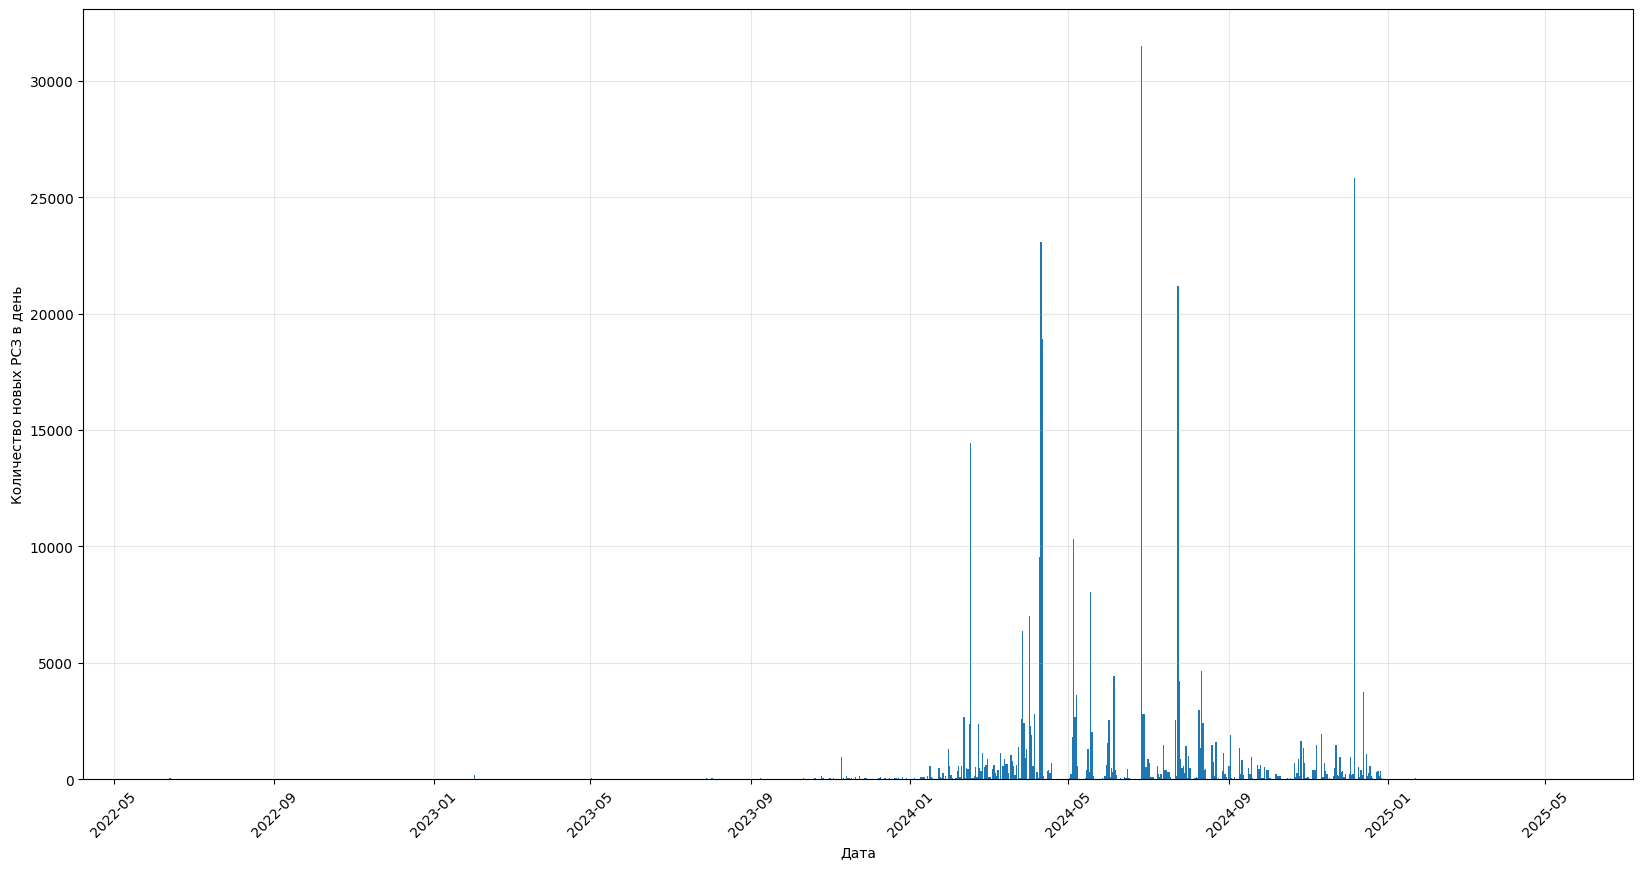

In [10]:
cloned_df = df.copy()
cloned_df = cloned_df[cloned_df['Статус РСЗ'] == 'Новое']
cloned_df['Дата'] = cloned_df['Дата изменения статуса РСЗ'].dt.date
# cloned_df = cloned_df[cloned_df['Дата изменения статуса РСЗ'] > '2024-06-01 00:00:00']
# cloned_df = cloned_df[cloned_df['Дата изменения статуса РСЗ'] < '2024-07-01 00:00:00']
bar_df = cloned_df.groupby('Дата')['Статус РСЗ'].count()
plt.figure(figsize=(20, 10))
plt.bar(x=bar_df.index, height=bar_df, width=1)
plt.xticks(rotation=45)
plt.ylabel('Количество новых РСЗ в день')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)
# plt.ylim(0, 100)

In [11]:
bar_df.sort_values()

Дата
2022-06-01        1
2022-11-18        1
2022-12-02        1
2023-01-23        1
2025-01-16        1
              ...  
2024-04-11    18935
2024-07-24    21205
2024-04-10    23075
2024-12-06    25832
2024-06-26    31512
Name: Статус РСЗ, Length: 481, dtype: int64

In [12]:
cloned_df
daily_counts = cloned_df[['№ схемы/риска', 'Дата изменения статуса РСЗ']].set_index('Дата изменения статуса РСЗ').resample('D').size().reset_index(name='count')
daily_counts['year'] = daily_counts['Дата изменения статуса РСЗ'].dt.year
daily_counts

daily_counts.groupby('year').agg(
    total_tasks=('count', 'sum'),            # Общее количество задач за год
    max_daily_tasks=('count', 'max'),        # Максимальное количество задач в день
    avg_daily_tasks=('count', 'mean')        # Среднее количество задач в день
).reset_index()

,year,total_tasks,max_daily_tasks,avg_daily_tasks
0,2022,82,32,0.383178
1,2023,3479,965,9.531507
2,2024,327950,31512,896.038251
3,2025,78,37,0.582090


In [13]:
# аrtifacts_list =  [7811755,  9346950,  9430063,  9446746,  9448905,  9451172,  9951162,
#        10280672, 10297671, 10304978, 11646767, 13341131, 14949625, 15158496,
#        15179189, 15256689, 15357780]
# df[df['№ схемы/риска'] == 9451172]

In [14]:
df[df['Потенциальный ущерб, руб'] < -1]

,№ схемы/риска,Тип,Дата выявления,Статус РСЗ,Дата изменения статуса РСЗ,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат","Потенциальный ущерб, руб",Номер проверки,ИНН НП,...,Код периода,Период,Год декларации,Номер корректировки,Дата подачи декларации,Вид налога,Тип декларации,Дата обновления,Дата аннулирования НД,Дата окончания КНП


## Распределение баллов по задачам и инспекторам в соответствии с автостатусами

In [15]:
copy_df = df.copy()

In [16]:
# 20% в новое
def get_new_type_data(day: str = '2024-06-27', df: pd.DataFrame = copy_df):
    # df = df.sort_values(['№ схемы/риска', 'Дата изменения статуса РСЗ'])
    day += ' 00:00:00'
    date_format = '%Y-%m-%d %H:%M:%S'
    day_str = datetime.strptime(day, date_format)
    day_before_str = day_str - timedelta(days=1)
    
    day_df = df[df['Дата изменения статуса РСЗ'] <= day_str]    

    cutten_day_df = day_df[day_df['Дата изменения статуса РСЗ'] > day_before_str]
    new_tasks_df = cutten_day_df[cutten_day_df['Статус РСЗ'] == 'Новое'].groupby('№ схемы/риска')[['Статус РСЗ', 'Тип', 'Дата изменения статуса РСЗ', 'Потенциальный ущерб, руб', 'ИНН НП']].last()
    
    inwork_tasks_df = df[df['Дата изменения статуса РСЗ'] <= day_before_str].groupby('№ схемы/риска')[['Статус РСЗ', 'Тип', 'Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат', 'Дата изменения статуса РСЗ', 'Потенциальный ущерб, руб', 'ИНН НП']].last()
    new_tasks_df = pd.concat([new_tasks_df, inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] == 'Новое']])
    new_tasks_df.drop(columns=['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат'], inplace=True)
    inwork_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] != 'Новое']
    finish_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] != 'В работе']
    inwork_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] == 'В работе']
    
    return new_tasks_df, inwork_tasks_df, finish_tasks_df

In [17]:
new_tasks_df, inwork_tasks_df, finish_tasks_df = get_new_type_data('2024-06-27')

In [18]:
# Автораздача РСЗ по ИНН
inn_df = inwork_tasks_df.groupby('ИНН НП')[['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат']].last() #Большая заглушка не все работы с одним ИНН идут одному работнику. Даже ни в один ТНО порой. Пример ИНН: 972-qyi-xxuq-qkjkk
auto_dis = new_tasks_df.merge(inn_df, how='inner', left_on='ИНН НП', right_index=True)
inwork_tasks_df = pd.concat([inwork_tasks_df, auto_dis])
new_tasks_df.drop(index=auto_dis.index, inplace=True)
auto_dis

,Статус РСЗ,Тип,Дата изменения статуса РСЗ,"Потенциальный ущерб, руб",ИНН НП,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат"
№ схемы/риска,,,,,,,
6750711,Новое,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,57803-sqnl-gwvmnj-uqvvyzki,7708
7696445,Новое,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,57803-sqnl-gwvmnj-uqvvyzki,7708
7807914,Новое,RISK_SHORT,2024-06-26 12:22:00,2240982.2,750-vdi-otro-pvugc,51465-moum-qjwvyg-ccddrmiq,4300
8655780,Новое,RISK_SHORT,2024-06-26 22:39:18,1225448.0,901-rlu-yhcx-ejmrz,81591-piom-czhlxo-aawpfqte,7100
9366155,Новое,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,57803-sqnl-gwvmnj-uqvvyzki,7708
...,...,...,...,...,...,...,...
9370284,Новое,RISK_SHORT,2024-06-13 06:30:27,249371.0,286-qow-nqlq-tvcdu,81781-pryv-kxalnx-kcrzfxrt,900
9384428,Новое,RISK_SHORT,2024-06-15 04:31:56,43664.0,706-qiz-ebep-pohao,38450-frov-dxzgvf-fftbutyq,500
9418395,Новое,SCHEMA,2024-06-25 17:30:21,1126256.0,270-jkk-zaic-brscf,12738-uehh-yrpezh-cwlmyqkm,7842


In [19]:
print('Число новых РСЗ поступивших в этот день в налоговую:', len(new_tasks_df))

Число новых РСЗ поступивших в этот день в налоговую: 31563


In [20]:
Auto_Stats = pd.DataFrame({
 'Новое':                                                   [0, 0, 0, 0],
 'В работе':                                                [0, 0, 0, 0],
 'Нарушение подтверждено. Устранено уточнением сведений':   [100, 86, 46, 0],
 'Нарушение не подтверждено':                               [50, 43, 23 , 0],
 'Нарушение подтверждено. Доказано':                        [75, 65, 35, 0],
 'Установлены отрицательные изменения':                     [0, 0, 0, 0],
 'Нарушение подтверждено. Не доказано':                     [40, 34, 18, 0],
 'Не доказано':                                             [40, 34, 18, 0],
 'Декларация аннулирована':                                 [60, 52, 28, 0],
 'Разакцептование':                                         [0, 0, 0, 0],
 'Архив':                                                   [0, 0, 0, 0],
 'Ожидает обработки':                                       [0, 0, 0, 0],
 'Разакцептован':                                           [0, 0, 0, 0],
 'На проверке':                                             [0, 0, 0, 0],
 'Выполнено':                                               [0, 0, 0, 3], 
 'Не выполнено':                                            [0, 0, 0, 0],
}).transpose()
Auto_Stats.columns = ['SCHEMA', 'RISK_LONG', 'RISK_SHORT', 'TASK']

In [21]:
all_scores = [Auto_Stats.loc[stat, df.iloc[i, 1]] for i, stat in enumerate(finish_tasks_df['Статус РСЗ'])]
finish_tasks_df['Score'] = all_scores
finish_tasks_df

,Статус РСЗ,Тип,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат",Дата изменения статуса РСЗ,"Потенциальный ущерб, руб",ИНН НП,Score
№ схемы/риска,,,,,,,,
4944803,Архив,RISK_LONG,84725-ywzo-dwypzb-dkqyibvy,7727,2024-03-01 12:42:21,33024.00,951-jcj-ovsl-xexdz,0
4950646,Архив,RISK_LONG,65221-yoto-fpnfvk-ljuqhapf,7000,2024-06-19 04:23:42,10158.48,931-jab-mmsl-gblig,0
4950777,Нарушение подтверждено. Доказано,RISK_LONG,20348-icof-oamlkh-idstpyvq,6316,2024-04-17 08:06:41,259009.60,378-uui-bxkr-yhlem,65
4951607,Нарушение не подтверждено,RISK_LONG,48306-zpes-keykzc-tzlhtgvc,6316,2024-04-17 08:07:22,162533.17,526-nfc-mawy-ugjmj,43
4952608,Нарушение не подтверждено,RISK_SHORT,80972-fkff-abpanr-jrhrknmk,5100,2022-01-24 08:15:40,73335.50,888-loq-kczq-swdov,43
...,...,...,...,...,...,...,...,...
9413623,Нарушение подтверждено. Доказано,RISK_LONG,81218-uhae-lhjrkn-hgzbgeat,6700,2024-06-18 17:02:31,1997.00,707-wnm-ldaf-wgjlb,65
9413685,Нарушение подтверждено. Не доказано,RISK_SHORT,66206-dlct-jkilhg-xezazvxq,4800,2024-06-25 15:12:51,84843.00,276-luf-wlbz-bwzde,18
9413862,Нарушение не подтверждено,RISK_SHORT,76728-ectf-oanuyq-xhwjwilt,7452,2024-06-18 10:30:24,166667.00,293-ybb-lccj-wtucz,23


In [22]:
N_ended_works = finish_tasks_df[finish_tasks_df['Score'] > 0].groupby('Инспектор, сменивший статус')['Score'].count()
N_ended_works

Инспектор, сменивший статус
11111-iyri-uwwjst-chzuradt    35
11125-pwzz-fygsdc-pkejzjik     3
11131-sfab-goldts-zajlmqic     1
11144-drfl-uxzbft-hnxymdov     4
11154-slzs-ahaxfb-jabdsspi     2
                              ..
99958-muml-yjokvs-nqgsmcoi     1
99962-xuim-lxusxl-liyswlzm     1
99969-qxfc-eirral-zrzcrexd    23
99981-ohqn-cntirp-negogxqs     4
99989-hjji-oyrmzp-aizmuiyk     6
Name: Score, Length: 8526, dtype: int64

## Создание датасета о инструктарах

In [23]:
inspectors_df = pd.DataFrame(copy_df.groupby('Инспектор, сменивший статус')['Код НО инспектора, сменившего стат'].last())
inspectors_efficiency = finish_tasks_df[finish_tasks_df['Score'] > 0].groupby('Инспектор, сменивший статус')['Score'].sum()/N_ended_works/100
inspectors_df = inspectors_df.merge(inspectors_efficiency, how='left', left_index=True, right_index=True)
inspectors_df.fillna(0, inplace=True)
inspectors_df['Experience'] = [np.random.random()/2 for i in range(len(inspectors_df))]
inspectors_df['Qualification'] = inspectors_df['Score'] + inspectors_df['Experience']

mask = inspectors_df['Qualification'] >= 0.71

# Используем np.where для каждого столбца
inspectors_df['p_SCHEMA'] = np.where(mask, 0.5, 0)
inspectors_df['p_RISK_LONG'] = np.where(mask, 0.5, 0)
inspectors_df['p_RISK_SHORT'] = np.where(mask, 0, 0.5)
inspectors_df['p_TASK'] = np.where(mask, 0, 0.5)
inspectors_df

,"Код НО инспектора, сменившего стат",Score,Experience,Qualification,p_SCHEMA,p_RISK_LONG,p_RISK_SHORT,p_TASK
"Инспектор, сменивший статус",,,,,,,,
11111-iyri-uwwjst-chzuradt,3700,0.537143,0.084423,0.621566,0.0,0.0,0.5,0.5
11125-pwzz-fygsdc-pkejzjik,2100,0.773333,0.051634,0.824968,0.5,0.5,0.0,0.0
11130-paro-ajcqzn-ceqdxcxw,6608,0.000000,0.251276,0.251276,0.0,0.0,0.5,0.5
11131-sfab-goldts-zajlmqic,1100,0.230000,0.301862,0.531862,0.0,0.0,0.5,0.5
11132-fgon-zinrmu-koxfcmwo,2632,0.000000,0.384421,0.384421,0.0,0.0,0.5,0.5
...,...,...,...,...,...,...,...,...
99958-muml-yjokvs-nqgsmcoi,7720,0.500000,0.127659,0.627659,0.0,0.0,0.5,0.5
99962-xuim-lxusxl-liyswlzm,2100,0.460000,0.320505,0.780505,0.5,0.5,0.0,0.0
99969-qxfc-eirral-zrzcrexd,7724,0.510435,0.186542,0.696976,0.0,0.0,0.5,0.5


## Подготовка нераспределённых РСЗ

In [24]:
insp_df = copy_df.groupby('№ схемы/риска')[['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат']].last()
new_tasks_df = new_tasks_df.merge(insp_df, how='left', left_index=True, right_index=True)

In [25]:
distribution_new_tasks = {'RISK_SHORT': 1, 'SCHEMA': 1, 'RISK_LONG': 1, 'TASK': 1}
distribution_new_tasks.update((k, new_tasks_df['Тип'].value_counts().to_dict()[k]) for k in set(distribution_new_tasks) & set(new_tasks_df['Тип'].value_counts().to_dict()))
distribution_new_tasks

{'RISK_SHORT': 31467, 'SCHEMA': 84, 'RISK_LONG': 12, 'TASK': 1}

In [26]:
# Функция для разбиванию инспекторов и РСЗ по НО
def filter_by_no(no_code:int, dataframe:pd.DataFrame = new_tasks_df):
    no_inspectors_df = inspectors_df[inspectors_df['Код НО инспектора, сменившего стат'] == no_code]
    no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
    
    # Заспределяем новые задачи по НО    
    # dataframe = dataframe.merge(inspectors_df[['Код НО инспектора, сменившего стат']], how='left', left_on='Инспектор, сменивший статус', right_index=True)
    dataframe['Код НО инспектора, сменившего стат'] = dataframe['Код НО инспектора, сменившего стат'].fillna(0).astype(int)
    no_df = dataframe[dataframe['Код НО инспектора, сменившего стат'] == no_code]
    
    return no_inspectors_df, no_df,

In [27]:
def start_data_prep(inspectors_df: pd.DataFrame, df: pd.DataFrame, in_work: pd.DataFrame = None):
    # Расчёт вероятности передачи определённого типа задачи сотруднику --> np.array(сотрудники, типы задач)
    task_prob = [inspectors_df['p_SCHEMA'].to_list(), inspectors_df['p_RISK_LONG'].to_list(), inspectors_df['p_RISK_SHORT'].to_list(), inspectors_df['p_TASK'].to_list(),]
    task_prob = np.array([*zip(*task_prob)])
    
    # Определения числа распределяемых задач и числа сотрудников --> int, int
    N, M = df.__len__(), inspectors_df.__len__()
    
    # Создание массива хранящего в себе тип задачи по порядку --> np.array(число распределяемых задач)
    if in_work is not None:
        concate_df = pd.concat([df, in_work])
    else:
        concate_df = df
    task_cat = concate_df['Тип'].to_numpy()
    
    # Создание словаря хранящего количество распределяемых задач данного типа --> dict()
    den_TNO = {'RISK_SHORT': 1, 'SCHEMA': 1, 'RISK_LONG': 1, 'TASK': 1}
    den_TNO.update((k, concate_df['Тип'].value_counts().to_dict()[k]) for k in set(den_TNO) & set(concate_df['Тип'].value_counts().to_dict()))
    
    return task_prob, N, M, task_cat, den_TNO

### Функция расчёта нагрузки и эффективности

In [28]:
def evaluation(individual: list, den_TNO: dict, task_cat: np.array, task_prob: np.array, M: int, results: bool = False, current_individ: list = []):
    full_ind = individual + current_individ
    K1, K2, K3, K4 = 100, 80, 46, 3
    K_SUM = K1 + K2 + K3 + K4
    cnt = {cat: np.zeros(M, dtype=int) for cat in den_TNO} 
    for j, emp_idx in enumerate(full_ind):
        cnt[task_cat[j]][emp_idx] += 1
        
    nu = (
        cnt["SCHEMA"]     / den_TNO["SCHEMA"]     * K1 +
        cnt["RISK_LONG"]  / den_TNO["RISK_LONG"]  * K2 +
        cnt["RISK_SHORT"] / den_TNO["RISK_SHORT"] * K3 +
        cnt["TASK"]       / den_TNO["TASK"]       * K4
    ) / K_SUM * 100
    
    
    efficiency = (
        cnt["SCHEMA"]     * task_prob[:, 0]   / den_TNO["SCHEMA"]     +
        cnt["RISK_LONG"]  * task_prob[:, 1]   / den_TNO["RISK_LONG"]  +
        cnt["RISK_SHORT"] * task_prob[:, 2]   / den_TNO["RISK_SHORT"] +
        cnt["TASK"]       * task_prob[:, 3]   / den_TNO["TASK"]       
    ).sum() *100
    
    load = nu.max()
    if not results:
        return load, efficiency,
    return nu, efficiency,

### Функция оптимизации

In [29]:
def Multi_optimization(no_code: int, population_size: int = 200, epoches: int = 100, p_crossing: float = 0.5, p_mutation: float = 0.2):
    
    no_inspectors_df, in_work_no_df = filter_by_no(no_code,  inwork_tasks_df)

    in_work_indiv = in_work_no_df.merge(no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
    in_work_indiv = in_work_indiv['Inspector index'].to_list()
        
    no_inspectors_df, no_df = filter_by_no(no_code)
    task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df, in_work_no_df)
        
    func = partial(evaluation, den_TNO=den_TNO, task_cat=task_cat, task_prob=task_prob, M=M, current_individ=in_work_indiv)
    
    creator.create('FintesMulti', base.Fitness, weights=(-1, 1)) # load ↓, efficiency ↑
    creator.create('Individual', list, fitness=creator.FintesMulti)
    
    toolbox = base.Toolbox()
    fit1_stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
    fit2_stats = tools.Statistics(key=lambda ind: ind.fitness.values[1])

    mstats = tools.MultiStatistics(fit1=fit1_stats, fit2=fit2_stats)
    mstats.register("min", np.min)
    mstats.register("avg", np.mean)
    mstats.register("max", np.max)

    toolbox.register('attr_int', np.random.randint, 0, M)
    toolbox.register('individual', tools.initRepeat, creator.Individual, 
                    toolbox.attr_int, N)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", func)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register('mutate', tools.mutUniformInt,  low=0, up=M-1, indpb=0.05)
    toolbox.register('select', tools.selNSGA2)
    
    hall_of_fame = tools.HallOfFame(np.inf)
    population = toolbox.population(population_size)
    pop, logbook = algorithms.eaMuPlusLambda(population, 
                                    toolbox, 
                                    mu=population_size,
                                    lambda_=population_size,
                                    cxpb=p_crossing, mutpb=p_mutation, ngen=epoches, 
                                    halloffame=hall_of_fame,
                                    stats=mstats, verbose=True)
    
    pareto = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    uniq_pareto = []
    for ind in pareto:
        if ind not in uniq_pareto:
            uniq_pareto.append(ind)
            
    print("Len of Pareto set:", len(uniq_pareto))
    return hall_of_fame, uniq_pareto
    

## Оптимизация по выбраному НО

In [30]:
df['Код НО инспектора, сменившего стат'].nunique()

437

In [62]:
no_code = new_tasks_df.groupby('Код НО инспектора, сменившего стат')['Статус РСЗ'].count().sort_values(ascending=False).index[1] #new_tasks_df['Код НО инспектора, сменившего стат'].unique()[0]
no_code

np.int64(1800)

In [63]:
no_inspectors_df, no_df = filter_by_no(no_code)
no_inspectors_df, in_work_no_df = filter_by_no(no_code,  inwork_tasks_df)
task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df, in_work_no_df)
hall_of_fame, uniq_pareto = Multi_optimization(no_code)

C:\Users\zincc\AppData\Local\Temp\ipykernel_18268\3402775206.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\zincc\AppData\Local\Temp\ipykernel_18268\3402775206.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\zincc\AppData\Local\Temp\ipykernel_18268\3402775206.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

   	      	                 fit1                 	                 fit2                 
   	      	--------------------------------------	--------------------------------------
gen	nevals	avg    	gen	max    	min    	nevals	avg    	gen	max    	min    	nevals
0  	200   	7.74878	0  	7.94842	7.64755	200   	65.2772	0  	66.7294	63.5576	200   
1  	143   	7.73188	1  	7.85993	7.61215	143   	65.7294	1  	66.9937	64.4827	143   
2  	145   	7.72454	2  	7.85993	7.61215	145   	65.9961	2  	67.0377	64.4827	145   
3  	129   	7.71383	3  	7.82453	7.61215	129   	66.1307	3  	67.0818	64.8351	129   
4  	133   	7.70702	4  	7.82453	7.61215	133   	66.3322	4  	67.1259	65.1435	133   
5  	138   	7.69675	5  	7.80683	7.61215	138   	66.464 	5  	67.3021	64.9673	138   
6  	143   	7.68949	6  	7.78914	7.61215	143   	66.5888	6  	67.3021	65.1435	143   
7  	152   	7.68259	7  	7.80683	7.61215	152   	66.6728	7  	67.5664	65.1435	152   
8  	137   	7.67914	8  	7.82453	7.61215	137   	66.7419	8  	67.6104	65.0994	137   
9  	146   	7

In [64]:
no_inspectors_df[no_inspectors_df['Qualification'] > 0.71]

,"Код НО инспектора, сменившего стат",Score,Experience,Qualification,p_SCHEMA,p_RISK_LONG,p_RISK_SHORT,p_TASK,Inspector index
"Инспектор, сменивший статус",,,,,,,,,
11995-qyrj-rblfdd-xncuxjwu,1800,0.453333,0.388758,0.842091,0.5,0.5,0.0,0.0,1
14676-cxbs-fhefgp-fuhtyueg,1800,0.425385,0.334120,0.759505,0.5,0.5,0.0,0.0,4
18149-gxwb-rwigtv-bifysero,1800,0.458571,0.445101,0.903672,0.5,0.5,0.0,0.0,6
20816-rdld-nxkuvj-czgiinbn,1800,0.604486,0.290577,0.895063,0.5,0.5,0.0,0.0,8
24652-wmvu-lcblim-yaitxjsu,1800,0.692000,0.477109,1.169109,0.5,0.5,0.0,0.0,12
38818-ysub-twfzsa-pvwoytoe,1800,0.550000,0.389111,0.939111,0.5,0.5,0.0,0.0,23
41802-qemo-vqasoa-dwthfbbd,1800,0.469012,0.368675,0.837687,0.5,0.5,0.0,0.0,25
43362-mrda-ktwvie-yjndgunx,1800,0.671159,0.230424,0.901584,0.5,0.5,0.0,0.0,28
48137-jmqs-bmnvxr-vpwfucti,1800,0.640000,0.212569,0.852569,0.5,0.5,0.0,0.0,31


### Анализ существуюшей нагрузки и её эффективности

C:\Users\zincc\AppData\Local\Temp\ipykernel_18268\3402775206.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Text(0.5, 1.0, 'Эффективность 59.45%')

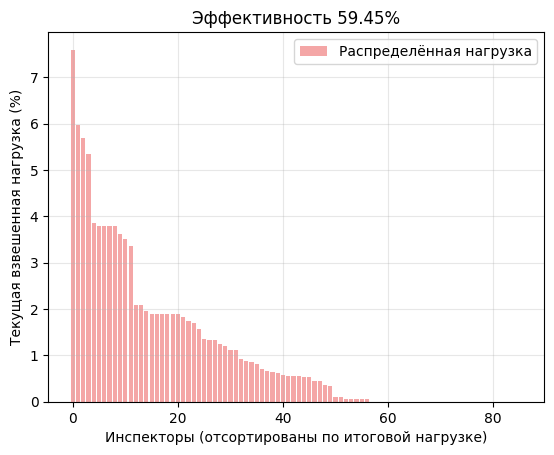

In [65]:
current_no_inspectors_df, current_no_df = filter_by_no(no_code, inwork_tasks_df)
current_task_prob, current_N, current_M, current_task_cat, current_den_TNO = start_data_prep(current_no_inspectors_df, current_no_df)
current_no_df = current_no_df.merge(current_no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
current_individ = current_no_df['Inspector index'].to_list()

current_load, current_eff = evaluation(current_individ, den_TNO=current_den_TNO, task_cat=current_task_cat, M=current_M, task_prob=current_task_prob, results=True)
sorted_current_load = np.sort(current_load)[::-1]
index = [i for i in range(len(current_no_inspectors_df))]

plt.bar(x=index, height=sorted_current_load, width=0.8, label='Распределённая нагрузка', color='lightcoral',  alpha = 0.7)
plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
plt.ylabel('Текущая взвешенная нагрузка (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Эффективность {round(current_eff, 2)}%')

### Анализ результатов оптимизации распределения новых задач

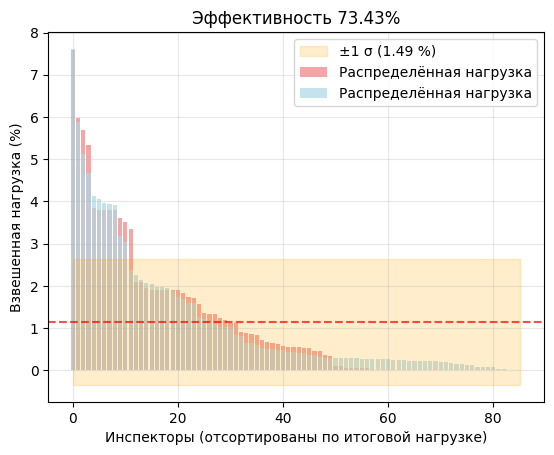

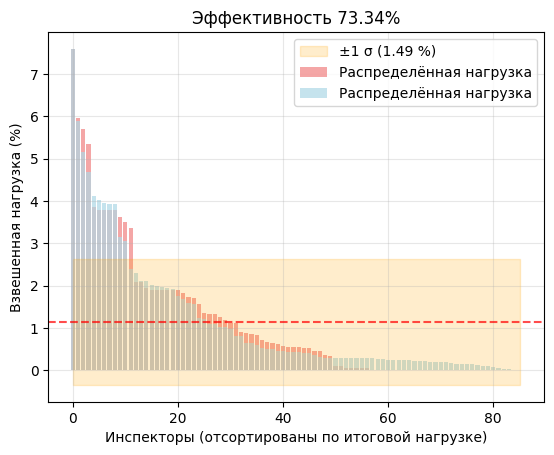

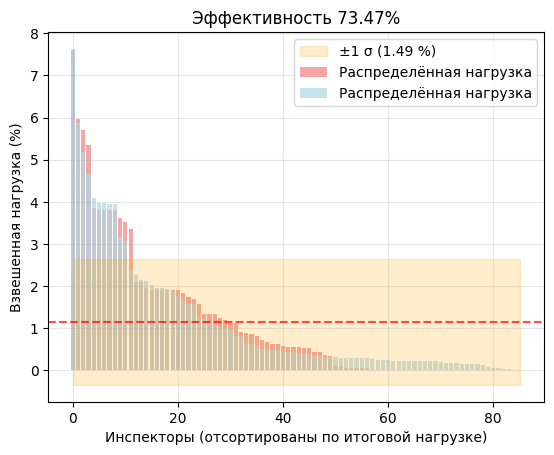

In [66]:
index = [i for i in range(len(no_inspectors_df))]
for pareto_ind in uniq_pareto:
    load, eff = evaluation(pareto_ind, den_TNO, task_cat, task_prob, M, results=True, current_individ=current_individ)
    sorted_load = np.sort(load)[::-1]
    current_mean = load.mean()
    std = load.std()    
    plt.bar(x=index, height=sorted_current_load, width=0.8, label='Распределённая нагрузка', color='lightcoral',  alpha = 0.7)
    plt.bar(x=index, height=sorted_load, width=0.8, label='Распределённая нагрузка', color='lightblue',  alpha = 0.7)
    plt.axhline(y=current_mean, color='red', linestyle='--', alpha=0.7)
    plt.fill_between(x=index, y1=current_mean - std, y2=current_mean + std,
                 color="orange", alpha=0.2, label=f"±1 σ ({std:.2f} %)")
    plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
    plt.ylabel('Взвешенная нагрузка (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'Эффективность {round(eff, 2)}%')
    plt.show()
# improvement = ((current_mean - final_mean) / current_mean * 100) if current_mean > 0 else 0
# ax1.axhline(y=final_mean, color='blue', linestyle='--', alpha=0.7)

In [36]:
all_generations = hall_of_fame.items
# all_generations.
populations = [ind.fitness.values for ind in all_generations]
populations = [[value[0], value[1]] for value in populations]
populations = [*zip(*populations)]
populations.append(tuple(all_generations))

pareto_front = [ind.fitness.values for ind in uniq_pareto]
pareto_front = [[value[0], value[1]] for value in pareto_front]
pareto_front = [*zip(*pareto_front)]
pareto_front.append(tuple(uniq_pareto))

In [37]:
import plotly.graph_objects as go
from ipywidgets import Output
import ipywidgets as widgets

output_area = Output()

fig = go.FigureWidget()
# fig.update_yaxes(range=[0, 100])
# fig.update_xaxes(range=[0, 10])
fig.add_trace(go.Scatter(x=populations[0], y=populations[1], mode='markers',  marker_color="royalblue", name='populations', customdata=populations[2]))
fig.add_trace(go.Scatter(x=pareto_front[0], y=pareto_front[1], mode='markers',  marker_color="Red", name='pareto front', customdata=pareto_front[2]))
fig.update_layout(title="Distribution of individuals",
                xaxis_title='max load, %',
                yaxis_title='eff, %',
                margin=dict(l=0, r=0, t=30, b=0))
fig.update_traces(hoverinfo="all", hovertemplate="Макс. нагрузка: %{x}<br>Эффективность: %{y}")

# Функция обработки клика
def handle_click(trace, points, selector):
    if points.point_inds:
        index = points.point_inds[0]
        with output_area:
            output_area.clear_output()
            print(f"Тип данных: {trace.name}")
            print(f"Индекс точки: {index}")
            print("Список параметров:")
            # Предполагаем, что customdata[index] - это список параметров
            for i, param in enumerate(trace.customdata[index]):
                print(f"Параметр {i+1}: {param}")

# Регистрируем обработчики
fig.data[0].on_click(handle_click)
fig.data[1].on_click(handle_click)

# Отображаем график и область вывода
display(widgets.VBox([fig, output_area]))

    'data': [{'customdata': [[16, 58, 10, 18, 74, 32, 78, 55, 19, 20, 30, 84, 47…

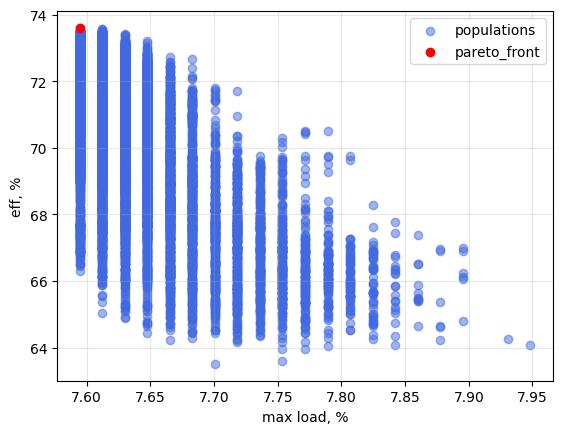

In [38]:
# vals = logbook.select("values")

# Получаем все сохраненные популяции
all_generations = hall_of_fame.items
# all_generations.
populations = [ind.fitness.values for ind in all_generations]
populations = [[value[0], value[1]] for value in populations]
populations = [*zip(*populations)]

pareto_front = [ind.fitness.values for ind in uniq_pareto]
pareto_front = [[value[0], value[1]] for value in pareto_front]
pareto_front = [*zip(*pareto_front)]

plt.scatter(populations[0], populations[1], c='royalblue', alpha=0.5)
plt.scatter(pareto_front[0], pareto_front[1], c='red')
plt.legend(['populations', 'pareto_front'])
plt.xlabel('max load, %')
plt.ylabel('eff, %')
plt.grid(True, alpha=0.3)

In [39]:
# individ = uniq_pareto[0] + current_individ
# result_df = pd.concat([no_df, current_no_df])[['Статус РСЗ', 'Тип']]
result_df = no_df[['Статус РСЗ', 'Тип', 'Потенциальный ущерб, руб',	'ИНН НП', 'Инспектор, сменивший статус']].copy()
result_df['New Inspector index'] = uniq_pareto[0]
result_df.reset_index(inplace=True)
result_df['Статус РСЗ'] = result_df['Статус РСЗ'].replace('Новое', 'В работе')
result_df = result_df.merge(no_inspectors_df.reset_index()[['Инспектор, сменивший статус', 'Inspector index']], how='left', left_on='New Inspector index', right_on='Inspector index')
result_df

,№ схемы/риска,Статус РСЗ,Тип,"Потенциальный ущерб, руб",ИНН НП,"Инспектор, сменивший статус_x",New Inspector index,"Инспектор, сменивший статус_y",Inspector index
0,9420917,В работе,RISK_SHORT,46795.0308,132-mfv-okif-eginh,85438-ihsc-dkzlnf-rzyqtakm,16,28441-cguk-wkwmve-vzlrzkaq,16
1,9420931,В работе,RISK_SHORT,15771.4849,650-oxr-nphw-irtcw,98765-jppk-fioqxr-wbqofdji,58,74416-voiq-zerflk-vrkiejfb,58
2,9420939,В работе,RISK_SHORT,40794.6204,355-zfm-ayji-jysid,47974-gmrb-zddxnh-pbspouyn,10,23015-msna-aimjwa-raftrhku,10
3,9421073,В работе,RISK_SHORT,8515.2048,837-bhf-vwni-bcgdb,98765-jppk-fioqxr-wbqofdji,18,31473-oghm-nsevqq-jdwmhokl,18
4,9421075,В работе,RISK_SHORT,7973.8674,525-zzd-vxhn-dpknp,34582-xhmh-yilulk-azgvtpvg,74,92045-twey-bvrqdt-bogbuell,74
...,...,...,...,...,...,...,...,...,...
770,9463230,В работе,RISK_SHORT,8944.3620,810-bfw-jiir-qfoqq,59474-lasp-ejebyh-ykhikilx,17,28918-zmjn-kkxvnx-ewntqvap,17
771,9463234,В работе,RISK_SHORT,120443.6316,748-frj-coxl-cwvxb,18149-gxwb-rwigtv-bifysero,63,80069-gsrh-zsupiz-pgqbzmrw,63
772,9463269,В работе,RISK_SHORT,66617.5229,990-wqx-gzpg-nabgw,47974-gmrb-zddxnh-pbspouyn,15,28278-wqxh-wviicr-ebaxlsip,15
773,9463345,В работе,RISK_SHORT,78826.1430,766-aol-vnur-jeiaq,50303-ytrp-cfxdre-kjrydskt,20,34582-xhmh-yilulk-azgvtpvg,20


In [67]:
result_df[result_df['Тип'] == 'SCHEMA']

,№ схемы/риска,Статус РСЗ,Тип,"Потенциальный ущерб, руб",ИНН НП,"Инспектор, сменивший статус_x",New Inspector index,"Инспектор, сменивший статус_y",Inspector index


In [50]:
current_no_df[current_no_df['Inspector index'] == 48]

,Статус РСЗ,Тип,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат",Дата изменения статуса РСЗ,"Потенциальный ущерб, руб",ИНН НП,Inspector index
№ схемы/риска,,,,,,,,
8642335,В работе,SCHEMA,60869-sizj-weykky-ywtshloc,1800,2024-05-20 08:12:14,5.402787e+06,808-dol-vjld-cqymm,48
8642464,В работе,SCHEMA,60869-sizj-weykky-ywtshloc,1800,2024-05-20 08:48:17,1.136820e+08,843-llr-ashx-pqffo,48
8646329,В работе,SCHEMA,60869-sizj-weykky-ywtshloc,1800,2024-05-20 09:36:57,9.978239e+06,338-xmc-nzrb-hiibs,48
8647351,В работе,SCHEMA,60869-sizj-weykky-ywtshloc,1800,2024-05-20 08:48:17,1.341930e+06,843-llr-ashx-pqffo,48


In [52]:
current_den_TNO

{'RISK_SHORT': 360, 'SCHEMA': 23, 'RISK_LONG': 98, 'TASK': 1}

In [40]:
# Код для работы Макара
# import pickle

# pareto_list = []
# pareto_list.append([ind.fitness.values for ind in uniq_pareto])
# for i in range(24):
#     pareto = tools.sortNondominated(random.sample(all_generations, 50), 50, first_front_only=True)[0]
#     uniq_pareto = []
#     for ind in pareto:
#         if ind not in uniq_pareto:
#             uniq_pareto.append(ind)
#     pareto_list.append([ind.fitness.values for ind in uniq_pareto])
# random.shuffle(pareto_list)

# # Saving the list to a file
# with open('my_list.pkl', 'wb') as f:
#     pickle.dump(pareto_list, f)
    
# with open('my_list.pkl', 'rb') as f:
#     loaded_list = pickle.load(f)

# print(len(loaded_list)) # Output: [1, 2, 3, 4, 5]